In [1]:
%load_ext autoreload
%autoreload 2

import sys
import random
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage

from src.config import OUTPUTS, IMG_SIZE, MLP_IMG_SIZE, IMAGENET_MEAN, IMAGENET_STD
from src.mlp import MLP, _cargar_split_pca
from src.cnn import CNN
from src.transfer import build_feature_extractor, build_fine_tuner
from src.data import ImageDataset, get_transforms

# Evaluación de Modelos - Clasificación Real vs Generado por IA

Comparación de cuatro modelos sobre el test set. Todos fueron entrenados con el mismo split de datos.

| Modelo | Enfoque | Input |
|--------|---------|-------|
| MLP | Red neuronal simple sobre features comprimidos con PCA (321 componentes) | 128x128 px |
| CNN | Red convolucional completa, entrenada de cero | 224x224 px |
| Transfer FE | ResNet50 preentrenada (solo se entrenó la capa de salida) | 224x224 px |
| Transfer FT | ResNet50 preentrenada (solo se entrenó la capa de salida y el último bloque convolucional) | 224x224 px |

## 1. MLP

In [2]:
# Cargar PCA y modelo
pca = joblib.load(OUTPUTS / "pca_mlp.joblib")

model = MLP(input_dim=pca.n_components_)
model.load_state_dict(torch.load(OUTPUTS / "mlp_best.pt", map_location="cpu"))
model.eval()

print(f"Componentes PCA: {pca.n_components_}")
print("Modelo cargado.")

Componentes PCA: 321
Modelo cargado.


In [3]:
# Cargar split de test y obtener predicciones
X_test, y_test = _cargar_split_pca("test", pca)

with torch.no_grad():
    logits = model(X_test)
    y_pred = (logits.sigmoid() >= 0.5).int().squeeze().numpy()

y_true = y_test.squeeze().int().numpy()

Cargando test:   0%|          | 0/5997 [00:00<?, ?it/s]

In [4]:
# Métricas
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1:        {f1_score(y_true, y_pred):.4f}")

Accuracy:  0.7237
Precision: 0.7017
Recall:    0.7787
F1:        0.7382


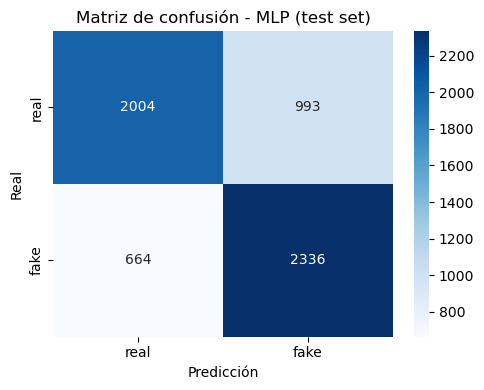

In [5]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - MLP (test set)")
plt.tight_layout()
plt.show()

In [6]:
# Distribución de probabilidades - MLP
probs_mlp = logits.sigmoid().squeeze().numpy()

filas = []
for i in range(10):
    lo = round(i / 10, 1)
    hi = round((i + 1) / 10, 1)
    mask = (probs_mlp >= lo) & (probs_mlp < hi) if i < 9 else (probs_mlp >= lo)
    filas.append({
        "Prob. fake": f"{lo:.1f} - {hi:.1f}",
        "Real": int(((y_true == 0) & mask).sum()),
        "Generada por IA": int(((y_true == 1) & mask).sum()),
    })

df_probs_mlp = pd.DataFrame(filas).set_index("Prob. fake")
df_probs_mlp["Total"] = df_probs_mlp["Real"] + df_probs_mlp["Generada por IA"]
print(df_probs_mlp.to_string())

            Real  Generada por IA  Total
Prob. fake                              
0.0 - 0.1    630               27    657
0.1 - 0.2    361               80    441
0.2 - 0.3    317              116    433
0.3 - 0.4    341              165    506
0.4 - 0.5    355              276    631
0.5 - 0.6    346              441    787
0.6 - 0.7    294              577    871
0.7 - 0.8    210              550    760
0.8 - 0.9    106              487    593
0.9 - 1.0     37              281    318


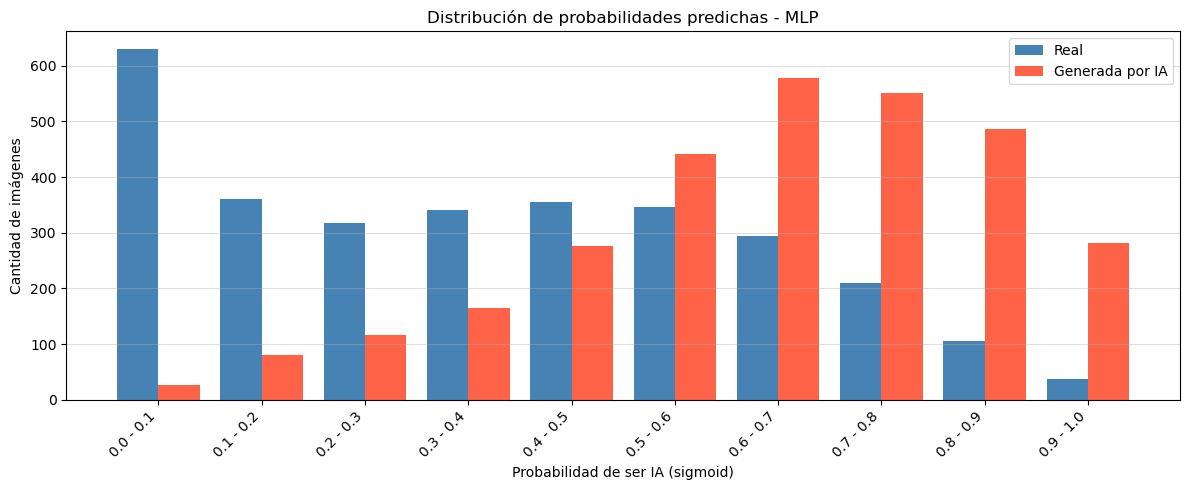

In [ ]:
bins_mlp = df_probs_mlp.index.tolist()
real_mlp = df_probs_mlp["Real"].values
ia_mlp = df_probs_mlp["Generada por IA"].values
x = range(len(bins_mlp))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], real_mlp, width=width, label="Real", color="steelblue")
ax.bar([i + width/2 for i in x], ia_mlp, width=width, label="Generada por IA", color="tomato")
ax.set_xticks(list(x))
ax.set_xticklabels(bins_mlp, rotation=45, ha="right")
ax.set_xlabel("Probabilidad de ser IA (sigmoid)")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución de probabilidades predichas - MLP")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

La distribución del MLP es la más dispersa de los cuatro modelos: muchas imágenes caen en el rango intermedio (0.3-0.7), lo que significa predicciones poco confiables. Esto es esperable, ya que PCA descarta información que el modelo podría usar para clasificar con más certeza. La separación entre clases existe (más imágenes reales a la izquierda, más IA a la derecha), pero el modelo asigna con frecuencia probabilidades ambiguas en vez de valores extremos como debería.

## 2. CNN

In [8]:
cnn_model = CNN()
cnn_model.load_state_dict(torch.load(OUTPUTS / "cnn_best.pt", map_location="cpu"))
cnn_model.eval()
print("CNN cargada.")

CNN cargada.


In [ ]:
test_loader = DataLoader(ImageDataset("test"), batch_size=128, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = cnn_model(imgs)
        preds = (logits.sigmoid() >= 0.5).int().squeeze()
        all_preds.append(preds)
        all_labels.append(labels)

y_pred_cnn = torch.cat(all_preds).numpy()
y_true_cnn = torch.cat(all_labels).numpy()

In [10]:
print(f"Accuracy:  {accuracy_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"Precision: {precision_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"Recall:    {recall_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"F1:        {f1_score(y_true_cnn, y_pred_cnn):.4f}")

Accuracy:  0.8843
Precision: 0.9037
Recall:    0.8603
F1:        0.8815


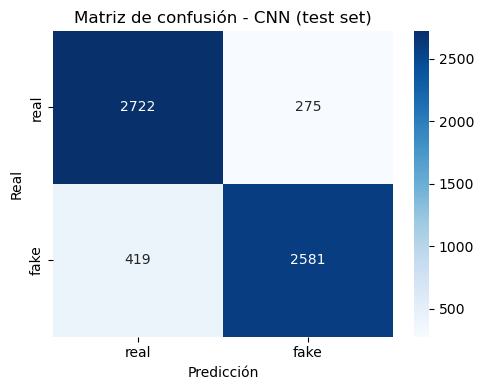

In [11]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - CNN (test set)")
plt.tight_layout()
plt.show()

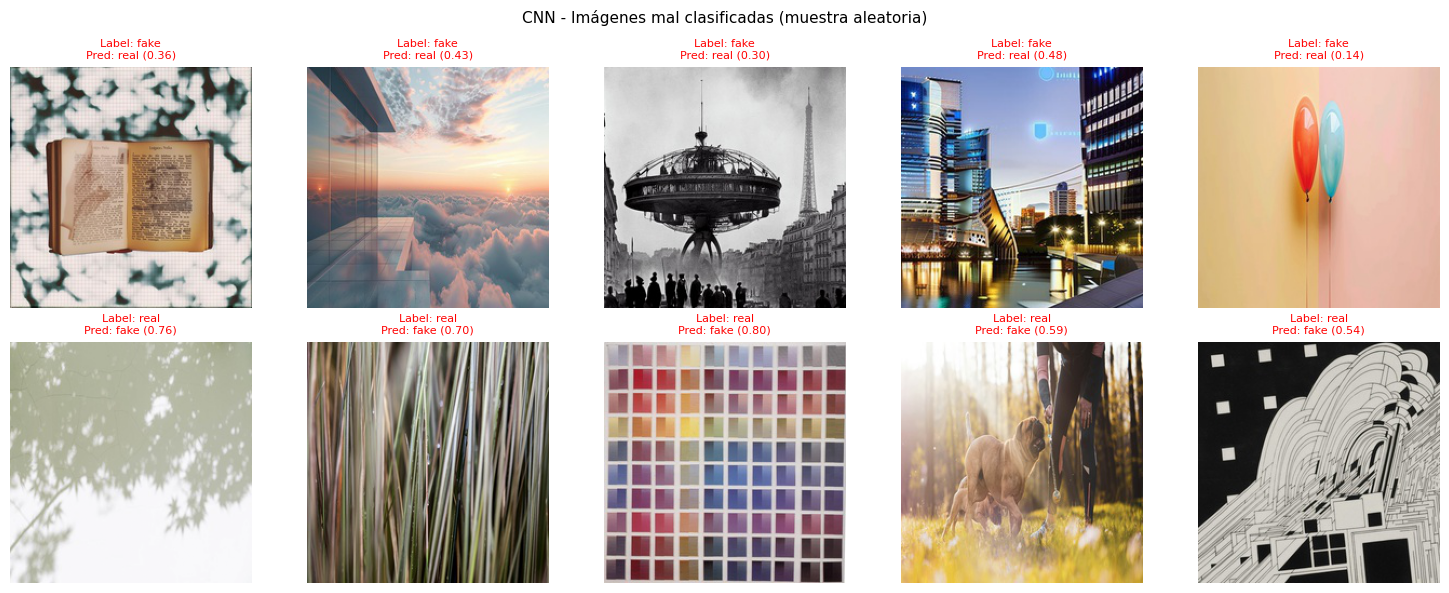

In [12]:
n = 10
dataset = ImageDataset("test")
INT_TO_LABEL = {0: "real", 1: "fake"}

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

errores = []
cnn_model.eval()
with torch.no_grad():
    for idx in random.sample(range(len(dataset)), len(dataset)):
        if len(errores) == n:
            break
        img_tensor, label_int = dataset[idx]
        prob = cnn_model(img_tensor.unsqueeze(0)).sigmoid().item()
        pred = "fake" if prob >= 0.5 else "real"
        real = INT_TO_LABEL[label_int]
        if pred != real:
            errores.append((img_tensor, real, pred, prob))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (img_tensor, real, pred, prob) in enumerate(errores):
    img_np = (img_tensor * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img_np)
    axes[i].set_title(f"Label: {real}\nPred: {pred} ({prob:.2f})", fontsize=8, color="red")
    axes[i].axis("off")

plt.suptitle("CNN - Imágenes mal clasificadas (muestra aleatoria)", fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
all_probs, all_labels_prob = [], []
cnn_model.eval()
with torch.no_grad():
    for imgs, labels in DataLoader(ImageDataset("test"), batch_size=128, shuffle=False):
        probs = cnn_model(imgs).sigmoid().squeeze()
        all_probs.append(probs)
        all_labels_prob.append(labels)

probs_np = torch.cat(all_probs).numpy()
labels_np = torch.cat(all_labels_prob).numpy()

filas = []
for i in range(10):
    lo = round(i / 10, 1)
    hi = round((i + 1) / 10, 1)
    mask = (probs_np >= lo) & (probs_np < hi) if i < 9 else (probs_np >= lo)
    filas.append({
        "Prob. fake": f"{lo:.1f} - {hi:.1f}",
        "Real": int(((labels_np == 0) & mask).sum()),
        "Generada por IA": int(((labels_np == 1) & mask).sum()),
    })

df_probs = pd.DataFrame(filas).set_index("Prob. fake")
df_probs["Total"] = df_probs["Real"] + df_probs["Generada por IA"]
print(df_probs.to_string())

            Real  Generada por IA  Total
Prob. fake                              
0.0 – 0.1   1884               79   1963
0.1 – 0.2    359               66    425
0.2 – 0.3    199               78    277
0.3 – 0.4    150              101    251
0.4 – 0.5    130               95    225
0.5 – 0.6     96              173    269
0.6 – 0.7     71              226    297
0.7 – 0.8     48              288    336
0.8 – 0.9     43              399    442
0.9 – 1.0     17             1495   1512


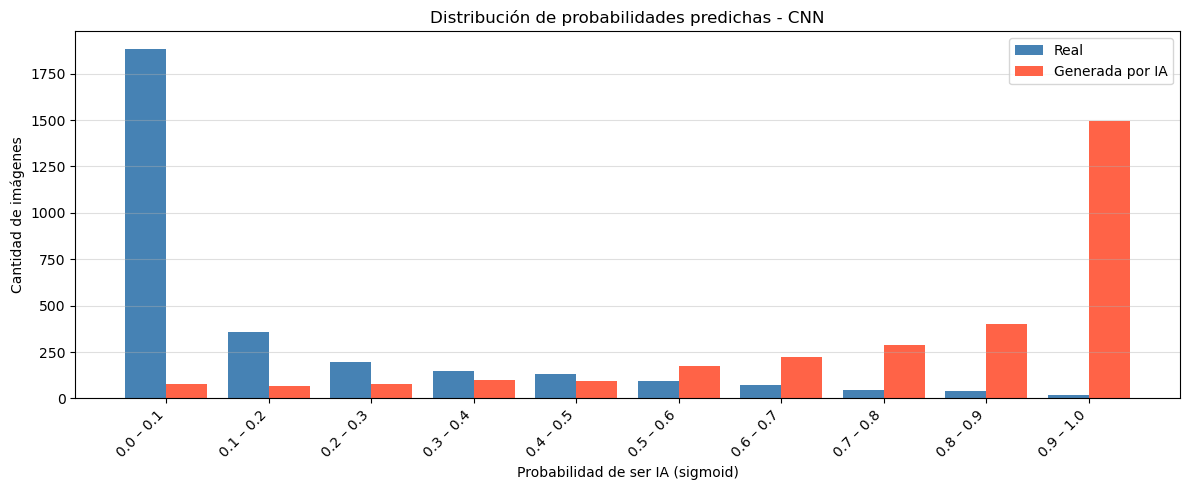

In [14]:
bins = df_probs.index.tolist()
real = df_probs["Real"].values
ia = df_probs["Generada por IA"].values
x = range(len(bins))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], real, width=width, label="Real", color="steelblue")
ax.bar([i + width/2 for i in x], ia, width=width, label="Generada por IA", color="tomato")

ax.set_xticks(list(x))
ax.set_xticklabels(bins, rotation=45, ha="right")
ax.set_xlabel("Probabilidad de ser IA (sigmoid)")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución de probabilidades predichas - CNN")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

La CNN muestra una distribución mucho más bimodal que el MLP: la mayoría de las imágenes reales cae en el rango 0.0-0.1 (1884 de 2997) y la mayoría de las generadas por IA en 0.9-1.0. Las capas convolucionales le permiten al modelo asignar predicciones más extremas y confiadas, lo que le da mayor accuracy respecto al MLP.

## 3. Transfer Learning - Feature Extraction (ResNet50)

In [15]:
fe_model = build_feature_extractor()
fe_model.load_state_dict(torch.load(OUTPUTS / "fe_best.pt", map_location="cpu"))
fe_model.eval()
print("Feature extraction model cargado.")

Feature extraction model cargado.


In [16]:
test_loader = DataLoader(ImageDataset("test"), batch_size=128, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = fe_model(imgs)
        preds = (logits.sigmoid() >= 0.5).int().squeeze()
        all_preds.append(preds)
        all_labels.append(labels)

y_pred_fe = torch.cat(all_preds).numpy()
y_true_fe = torch.cat(all_labels).numpy()

In [17]:
print(f"Accuracy:  {accuracy_score(y_true_fe, y_pred_fe):.4f}")
print(f"Precision: {precision_score(y_true_fe, y_pred_fe):.4f}")
print(f"Recall:    {recall_score(y_true_fe, y_pred_fe):.4f}")
print(f"F1:        {f1_score(y_true_fe, y_pred_fe):.4f}")

Accuracy:  0.8808
Precision: 0.8777
Recall:    0.8850
F1:        0.8813


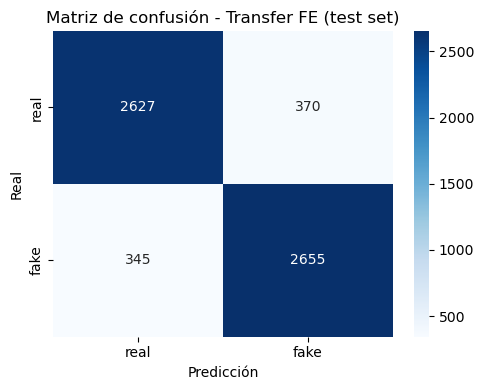

In [18]:
cm_fe = confusion_matrix(y_true_fe, y_pred_fe)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_fe, annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Transfer FE (test set)")
plt.tight_layout()
plt.show()

In [ ]:
# Distribución de probabilidades - Transfer FE
all_probs_fe2, all_labels_fe2 = [], []
fe_model.eval()
with torch.no_grad():
    for imgs, labels in DataLoader(ImageDataset("test"), batch_size=128, shuffle=False):
        probs = fe_model(imgs).sigmoid().squeeze()
        all_probs_fe2.append(probs)
        all_labels_fe2.append(labels)

probs_fe_np = torch.cat(all_probs_fe2).numpy()
labels_fe_np2 = torch.cat(all_labels_fe2).numpy()

filas = []
for i in range(10):
    lo = round(i / 10, 1)
    hi = round((i + 1) / 10, 1)
    mask = (probs_fe_np >= lo) & (probs_fe_np < hi) if i < 9 else (probs_fe_np >= lo)
    filas.append({
        "Prob. fake": f"{lo:.1f} - {hi:.1f}",
        "Real": int(((labels_fe_np2 == 0) & mask).sum()),
        "Generada por IA": int(((labels_fe_np2 == 1) & mask).sum()),
    })

df_probs_fe = pd.DataFrame(filas).set_index("Prob. fake")
df_probs_fe["Total"] = df_probs_fe["Real"] + df_probs_fe["Generada por IA"]
print(df_probs_fe.to_string())

            Real  Generada por IA  Total
Prob. fake                              
0.0 – 0.1   1651               57   1708
0.1 – 0.2    441               45    486
0.2 – 0.3    242               53    295
0.3 – 0.4    159               82    241
0.4 – 0.5    134              108    242
0.5 – 0.6    115              118    233
0.6 – 0.7     90              157    247
0.7 – 0.8     62              232    294
0.8 – 0.9     66              353    419
0.9 – 1.0     37             1795   1832


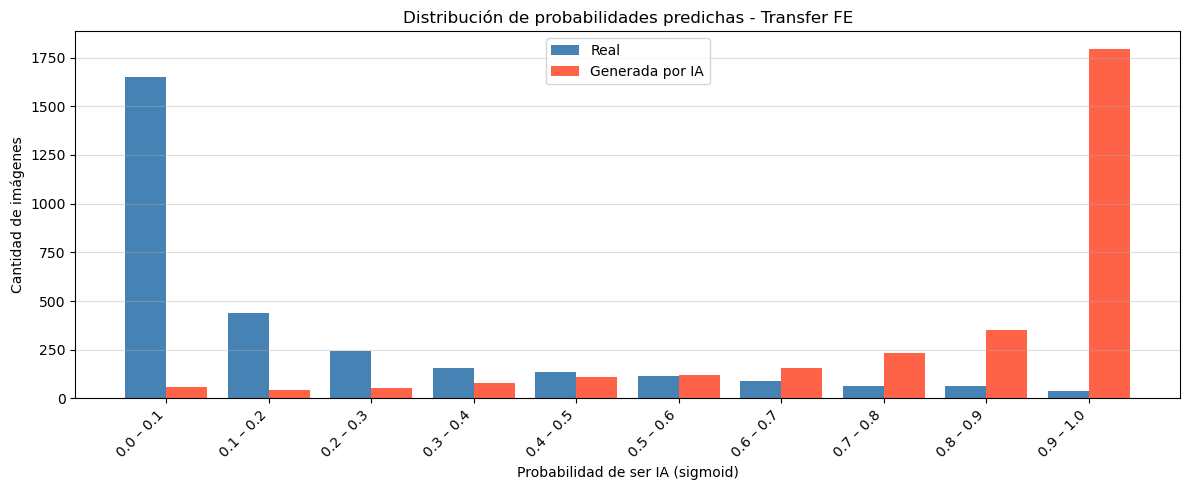

In [20]:
bins_fe = df_probs_fe.index.tolist()
real_fe = df_probs_fe["Real"].values
ia_fe = df_probs_fe["Generada por IA"].values
x = range(len(bins_fe))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], real_fe, width=width, label="Real", color="steelblue")
ax.bar([i + width/2 for i in x], ia_fe, width=width, label="Generada por IA", color="tomato")
ax.set_xticks(list(x))
ax.set_xticklabels(bins_fe, rotation=45, ha="right")
ax.set_xlabel("Probabilidad de ser IA (sigmoid)")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución de probabilidades predichas - Transfer FE")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

Feature Extraction muestra un patrón similar a la CNN, con la mayoría de las imágenes reales concentradas en 0.0-0.1 y las generadas por IA en 0.9-1.0. Es notable que con apenas 2049 parámetros entrenables, los features preentrenados de ResNet50 ya son lo suficientemente discriminativos como para generar predicciones muy polarizadas, alcanzando una accuracy casi igual que la de la CNN (88.1% vs 88.4%).

## 4. Transfer Learning - Fine-tuning (ResNet50)

In [21]:
ft_model = build_fine_tuner()
ft_model.load_state_dict(torch.load(OUTPUTS / "ft_best.pt", map_location="cpu"))
ft_model.eval()
print("Fine-tuning model cargado.")

Fine-tuning model cargado.


In [22]:
test_loader = DataLoader(ImageDataset("test"), batch_size=128, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = ft_model(imgs)
        preds = (logits.sigmoid() >= 0.5).int().squeeze()
        all_preds.append(preds)
        all_labels.append(labels)

y_pred_ft = torch.cat(all_preds).numpy()
y_true_ft = torch.cat(all_labels).numpy()

In [23]:
print(f"Accuracy:  {accuracy_score(y_true_ft, y_pred_ft):.4f}")
print(f"Precision: {precision_score(y_true_ft, y_pred_ft):.4f}")
print(f"Recall:    {recall_score(y_true_ft, y_pred_ft):.4f}")
print(f"F1:        {f1_score(y_true_ft, y_pred_ft):.4f}")

Accuracy:  0.9335
Precision: 0.9257
Recall:    0.9427
F1:        0.9341


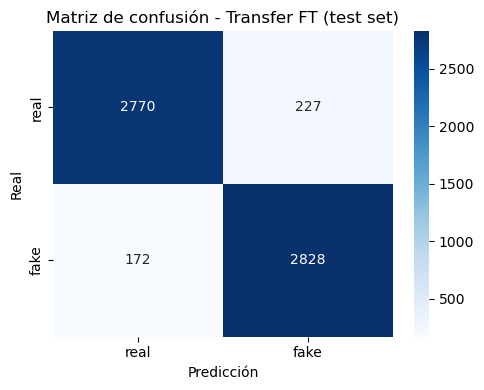

In [24]:
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_ft, annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Transfer FT (test set)")
plt.tight_layout()
plt.show()

In [ ]:
# Distribución de probabilidades - Transfer FT
all_probs_ft2, all_labels_ft2 = [], []
ft_model.eval()
with torch.no_grad():
    for imgs, labels in DataLoader(ImageDataset("test"), batch_size=128, shuffle=False):
        probs = ft_model(imgs).sigmoid().squeeze()
        all_probs_ft2.append(probs)
        all_labels_ft2.append(labels)

probs_ft_np = torch.cat(all_probs_ft2).numpy()
labels_ft_np2 = torch.cat(all_labels_ft2).numpy()

filas = []
for i in range(10):
    lo = round(i / 10, 1)
    hi = round((i + 1) / 10, 1)
    mask = (probs_ft_np >= lo) & (probs_ft_np < hi) if i < 9 else (probs_ft_np >= lo)
    filas.append({
        "Prob. fake": f"{lo:.1f} - {hi:.1f}",
        "Real": int(((labels_ft_np2 == 0) & mask).sum()),
        "Generada por IA": int(((labels_ft_np2 == 1) & mask).sum()),
    })

df_probs_ft = pd.DataFrame(filas).set_index("Prob. fake")
df_probs_ft["Total"] = df_probs_ft["Real"] + df_probs_ft["Generada por IA"]
print(df_probs_ft.to_string())

            Real  Generada por IA  Total
Prob. fake                              
0.0 – 0.1   2318               30   2348
0.1 – 0.2    211               24    235
0.2 – 0.3    102               33    135
0.3 – 0.4     80               41    121
0.4 – 0.5     59               44    103
0.5 – 0.6     62               35     97
0.6 – 0.7     38               41     79
0.7 – 0.8     41               69    110
0.8 – 0.9     45              123    168
0.9 – 1.0     41             2560   2601


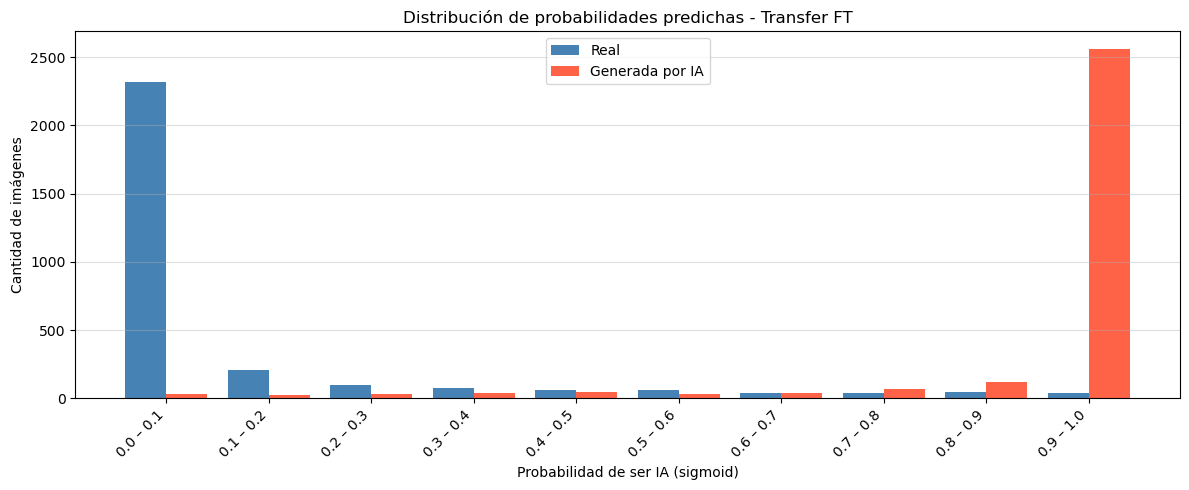

In [ ]:
bins_ft = df_probs_ft.index.tolist()
real_ft = df_probs_ft["Real"].values
ia_ft = df_probs_ft["Generada por IA"].values
x = range(len(bins_ft))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], real_ft, width=width, label="Real", color="steelblue")
ax.bar([i + width/2 for i in x], ia_ft, width=width, label="Generada por IA", color="tomato")
ax.set_xticks(list(x))
ax.set_xticklabels(bins_ft, rotation=45, ha="right")
ax.set_xlabel("Probabilidad de ser IA (sigmoid)")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución de probabilidades predichas - Transfer FT")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

El Fine-tuning produce la distribución más polarizada de los cuatro modelos: el 82% de las imágenes cae en los extremos (0.0-0.1 o 0.9-1.0). Las 2318 imágenes reales en el rango 0.0–0.1 representan el 77% de todas las reales, y las 2560 generadas en 0.9-1.0 representan el 85% de las IA. Adaptar layer4 al dominio específico permite al modelo distinguir con muy alta confianza, lo que le da una accuracy mayor (93.4%).

## 5. Comparación de Modelos

In [27]:
resultados = {
    "MLP": (y_true, y_pred),
    "CNN": (y_true_cnn, y_pred_cnn),
    "Transfer FE": (y_true_fe, y_pred_fe),
    "Transfer FT": (y_true_ft, y_pred_ft),
}

filas = []
for nombre, (yt, yp) in resultados.items():
    filas.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(yt, yp),
        "Precision": precision_score(yt, yp),
        "Recall": recall_score(yt, yp),
        "F1": f1_score(yt, yp),
    })

df_comp = pd.DataFrame(filas).set_index("Modelo")
print(df_comp.to_string(float_format=lambda x: f"{x:.4f}"))

             Accuracy  Precision  Recall     F1
Modelo                                         
MLP            0.7237     0.7017  0.7787 0.7382
CNN            0.8843     0.9037  0.8603 0.8815
Transfer FE    0.8808     0.8777  0.8850 0.8813
Transfer FT    0.9335     0.9257  0.9427 0.9341


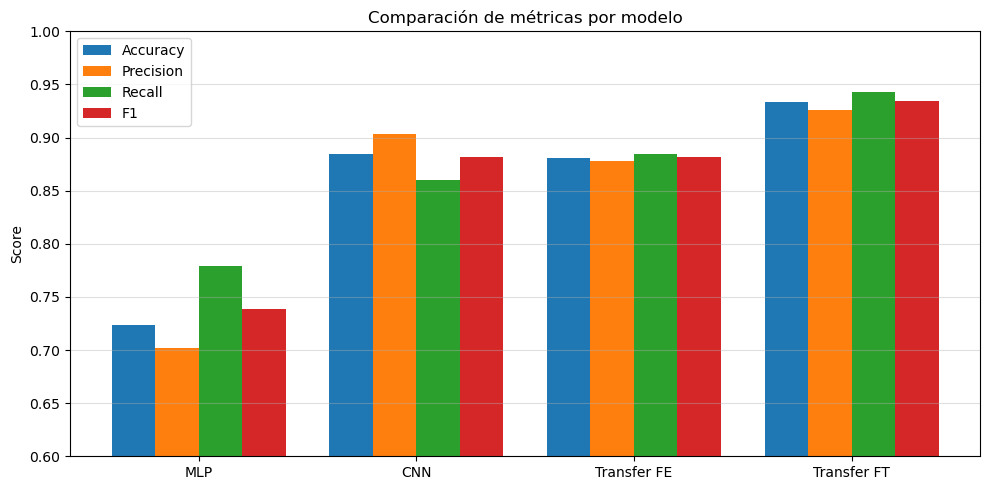

In [28]:
modelos = df_comp.index.tolist()
metricas = ["Accuracy", "Precision", "Recall", "F1"]
x = range(len(modelos))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, metrica in enumerate(metricas):
    ax.bar([xi + i * width for xi in x], df_comp[metrica], width=width, label=metrica)

ax.set_xticks([xi + width * 1.5 for xi in x])
ax.set_xticklabels(modelos)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel("Score")
ax.set_title("Comparación de métricas por modelo")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Umbral de Clasificación Óptimo

Por defecto los modelos clasifican como IA toda imagen con probabilidad ≥ 0.5. Ese umbral no necesariamente maximiza las métricas sobre los datos reales.

Usando la **curva ROC** sobre el validation set del mejor modelo (Transfer FT), buscamos el umbral que maximiza el **índice de Youden** (TPR − FPR): el punto de la curva más alejado de la diagonal aleatoria.

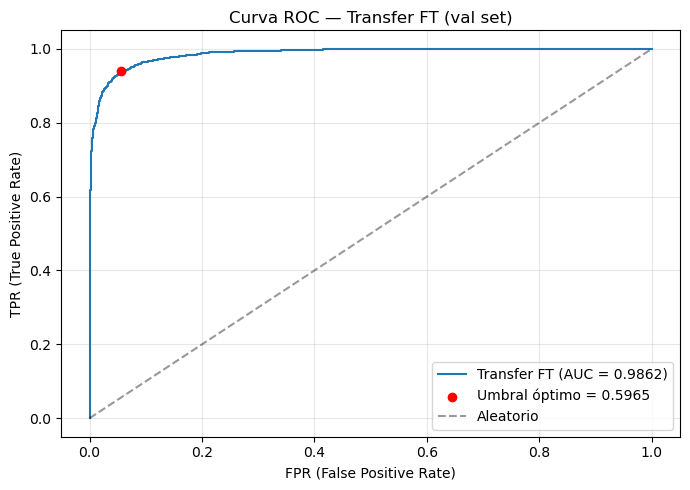

Umbral                          Accuracy  Precision  Recall      F1
-----------------------------------------------------------------
0.5000 (default)                  0.9377     0.9274  0.9497  0.9384
0.5965 (Youden)                   0.9413     0.9434  0.9390  0.9412


In [29]:
# Probabilidades del Transfer FT sobre val set
val_loader_roc = DataLoader(ImageDataset("val"), batch_size=128, shuffle=False)

all_probs_val, all_labels_val = [], []
ft_model.eval()
with torch.no_grad():
    for imgs, labels in val_loader_roc:
        probs = ft_model(imgs).sigmoid().squeeze()
        all_probs_val.append(probs)
        all_labels_val.append(labels)

probs_val = torch.cat(all_probs_val).numpy()
labels_val = torch.cat(all_labels_val).numpy()

# Curva ROC y umbral óptimo (índice de Youden)
fpr, tpr, thresholds = roc_curve(labels_val, probs_val)
auc = roc_auc_score(labels_val, probs_val)
best_idx = (tpr - fpr).argmax()
best_threshold = thresholds[best_idx]

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, label=f"Transfer FT (AUC = {auc:.4f})")
ax.scatter(fpr[best_idx], tpr[best_idx], color="red", zorder=5, label=f"Umbral óptimo = {best_threshold:.4f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aleatorio")
ax.set_xlabel("FPR (False Positive Rate)")
ax.set_ylabel("TPR (True Positive Rate)")
ax.set_title("Curva ROC — Transfer FT (val set)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Métricas con umbral 0.5 vs óptimo
print(f"{'Umbral':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>7} {'F1':>7}")
print("-" * 65)
for nombre, umbral in [("0.5000 (default)", 0.5), (f"{best_threshold:.4f} (Youden)", best_threshold)]:
    yp = (probs_val >= umbral).astype(int)
    print(f"{nombre:<30} {accuracy_score(labels_val, yp):>9.4f} "
          f"{precision_score(labels_val, yp):>10.4f} "
          f"{recall_score(labels_val, yp):>7.4f} "
          f"{f1_score(labels_val, yp):>7.4f}")

**Conclusión:** El umbral óptimo según el índice de Youden es **0.5965**, levemente por encima del 0.5 por defecto. Esto indica que el modelo tiende a ser algo conservador en sus probabilidades: necesita más confianza para clasificar una imagen como IA generada. Al subir el umbral, la precisión mejora de 0.9274 a 0.9434 (menos falsos positivos) a costa de una leve caída en recall (de 0.9497 a 0.9390). La mejora en F1 es marginal (+0.003), lo que confirma que el umbral de 0.5 ya es una elección razonable para este dataset balanceado.

## 7. Limitación del Modelo: Generalización Fuera de la Distribución

Una limitación importante de este modelo es que **solo generaliza correctamente dentro de la distribución del dataset de entrenamiento**. Las imágenes reales del dataset son paisajes, naturaleza, arquitectura y arte - no retratos ni selfies.

A continuación se muestra una foto real de una persona evaluada por los cuatro modelos:

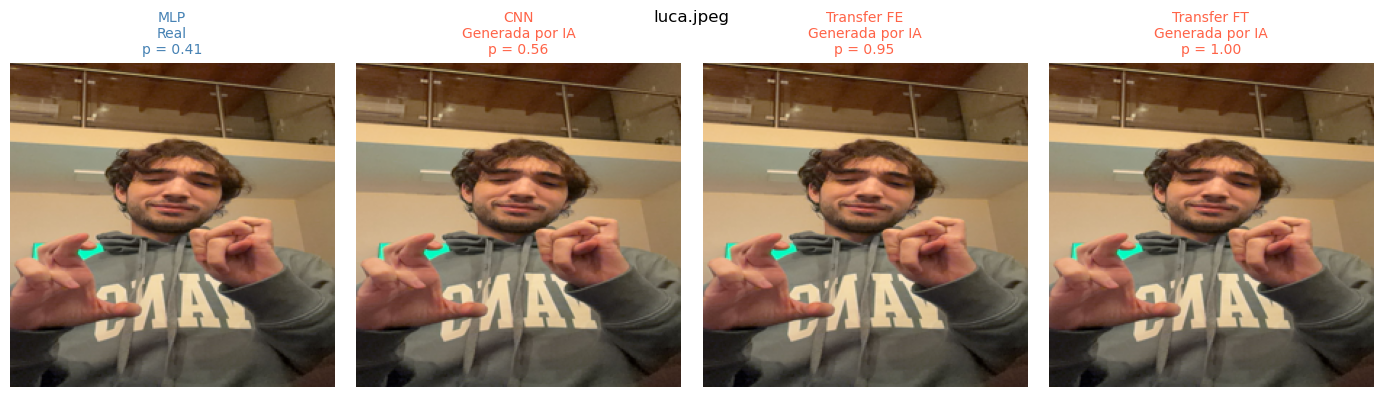

In [30]:
ruta = Path("imgs/luca.jpeg")

with PILImage.open(ruta) as img:
    img_rgb = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))

# Preprocesamiento compartido para CNN y Transfer (ya está a 224×224)
x_cnn = get_transforms("val")(img_rgb).unsqueeze(0)

# MLP
img_mlp = img_rgb.resize((MLP_IMG_SIZE, MLP_IMG_SIZE))
x_mlp = pca.transform(np.array(img_mlp, dtype=np.uint8).flatten().reshape(1, -1)).astype(np.float32)
with torch.no_grad():
    prob_mlp = model(torch.from_numpy(x_mlp)).sigmoid().item()

# CNN
with torch.no_grad():
    prob_cnn = cnn_model(x_cnn).sigmoid().item()

# Transfer FE
with torch.no_grad():
    prob_fe = fe_model(x_cnn).sigmoid().item()

# Transfer FT
with torch.no_grad():
    prob_ft = ft_model(x_cnn).sigmoid().item()

# Visualización
nombres = ["MLP", "CNN", "Transfer FE", "Transfer FT"]
probs = [prob_mlp, prob_cnn, prob_fe, prob_ft]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, nombre, prob in zip(axes, nombres, probs):
    pred = "Generada por IA" if prob >= 0.5 else "Real"
    color = "tomato" if pred == "Generada por IA" else "steelblue"
    ax.imshow(img_rgb)
    ax.set_title(f"{nombre}\n{pred}\np = {prob:.2f}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle(ruta.name, fontsize=12)
plt.tight_layout()
plt.show()

### ¿Por qué falla con esta imagen?

Los modelos CNN y Transfer clasifican la foto como generada por IA a pesar de ser real. Esto no es un error del modelo sino una consecuencia directa del dataset:

- Las imágenes **reales** del training set son paisajes, naturaleza, arquitectura y arte — nunca retratos.
- El modelo aprendió a distinguir "imagen original del dataset" vs "versión regenerada por IA de esa imagen", no el concepto general de "foto tomada por un humano".
- Una selfie tomada con un smartphone tiene patrones de textura, ruido y color distintos a los que el modelo aprendió a reconocer como "real".

**El propósito real del modelo** es detectar si una imagen de tipo paisaje, naturaleza o arte fue generada o modificada por IA, comparando la imagen con su distribución de entrenamiento. Dentro de esa distribución, los modelos alcanzan entre 72% y 93% de accuracy en el test set.

Este problema de generalización motivó el desarrollo de un **quinto modelo**: en el notebook 06 se realiza un fine-tuning incremental sobre imágenes de redes sociales (`itw-sm`) para adaptar el modelo a fotos cotidianas de galería.